IMPORTING


In [1]:
import pandas as pd

df = pd.read_csv("HR.csv")
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [2]:
print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [3]:
print(df['Attrition'].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [4]:
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

In [5]:
df_org = df.copy()

SPLIT THE DATA

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Attrition'])
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

VISUALIZATION

In [7]:
viz_df = pd.concat([X_train, y_train], axis = 1)

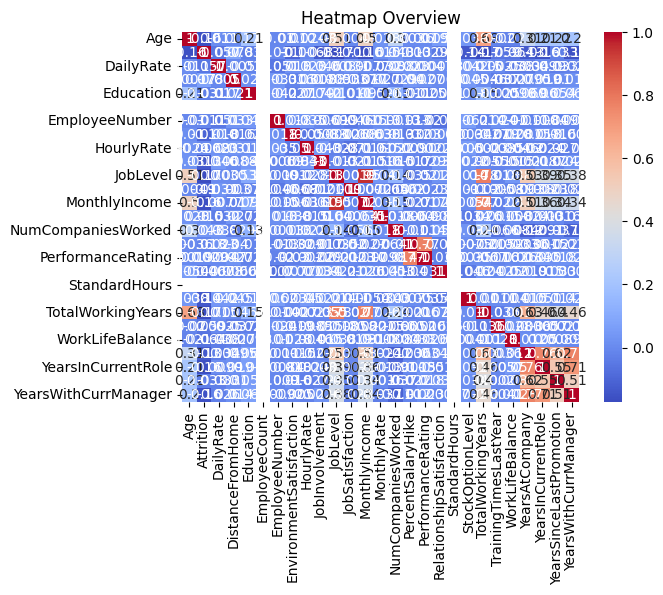

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.title("Heatmap Overview")
plt.show()

THIS IS BASICALLY UNREADABLE SO 

In [9]:
viz_df.select_dtypes(include='number').corr()['Attrition'].sort_values(ascending=False)

Attrition                   1.000000
DistanceFromHome            0.067886
NumCompaniesWorked          0.063013
MonthlyRate                 0.019092
HourlyRate                  0.003221
EmployeeNumber              0.000250
PerformanceRating          -0.005086
PercentSalaryHike          -0.017458
RelationshipSatisfaction   -0.018682
Education                  -0.022896
YearsSinceLastPromotion    -0.028593
DailyRate                  -0.039971
TrainingTimesLastYear      -0.060597
WorkLifeBalance            -0.064892
EnvironmentSatisfaction    -0.080855
JobSatisfaction            -0.104915
JobInvolvement             -0.117724
YearsAtCompany             -0.132936
Age                        -0.153240
StockOptionLevel           -0.155555
YearsWithCurrManager       -0.158191
MonthlyIncome              -0.159820
TotalWorkingYears          -0.169475
JobLevel                   -0.172187
YearsInCurrentRole         -0.177569
EmployeeCount                    NaN
StandardHours                    NaN
N

here correlation with EmployeeCount and StandardHours are basically NaN
so we drop them

In [10]:
df = df.drop(columns=['StandardHours', 'EmployeeCount'])

In [11]:
df = df.drop(columns=['EmployeeNumber', 'Over18'])

HERE DISTANCE FROM HOME IS CORELATED so let's see with box plot

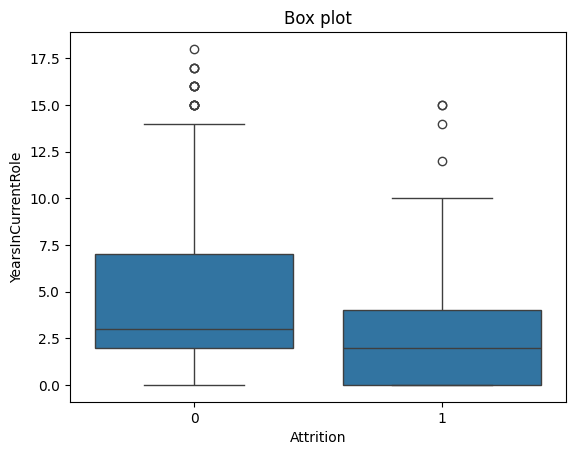

In [12]:
sns.boxplot(x='Attrition', y = 'YearsInCurrentRole', data = viz_df)
plt.title("Box plot")
plt.show()

Now we do OHE

In [13]:
cat_cols = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

In [14]:
X_train = pd.get_dummies(X_train, columns = cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

X_train, X_test = X_train.align(X_test, join = 'left', axis =1, fill_value = 0)

In [15]:
print(X_train.columns.tolist())

['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'Gender_Male', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_S

In [16]:
drop_cols = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

SCALING

In [17]:
from sklearn.preprocessing import StandardScaler

num_cols = ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 
            'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 
            'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 
            'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 
            'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 
            'YearsSinceLastPromotion', 'YearsWithCurrManager']

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

TRAINING NOW        

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(), 
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name}: Train: {train_acc}, Test: {test_acc}")

Logistic Regression: Train: 0.8928571428571429, Test: 0.8877551020408163
Decision Tree: Train: 1.0, Test: 0.7653061224489796
Random Forest: Train: 1.0, Test: 0.8741496598639455


HERE MOST OF THE ATTRITION IS YES SO TO FIND OUT IF THEY ARE PREDICTING OR JUST SAYING YES.. WE DO CLASSIFICATION REPORT

In [19]:
from sklearn.metrics import classification_report

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       255
           1       0.61      0.44      0.51        39

    accuracy                           0.89       294
   macro avg       0.76      0.70      0.72       294
weighted avg       0.88      0.89      0.88       294


Decision Tree
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       255
           1       0.16      0.18      0.17        39

    accuracy                           0.77       294
   macro avg       0.52      0.52      0.52       294
weighted avg       0.78      0.77      0.77       294


Random Forest
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.67      0.10      0.18        39

    accuracy                           0.87       294
   macro avg       0.77      0.55      0.55       294
weighted avg       0.85

WE ARE BALANCING THE WEIGHT OF LEAVERS AND STAYERS 

In [20]:
lr = LogisticRegression(random_state=42, max_iter= 1000, class_weight='balanced')
lr.fit (X_train, y_train)
y_pred = lr.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.74      0.82       255
           1       0.25      0.56      0.34        39

    accuracy                           0.71       294
   macro avg       0.58      0.65      0.58       294
weighted avg       0.83      0.71      0.75       294



Now we tune the LR model

In [21]:
from sklearn.model_selection import GridSearchCV

lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}

grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    lr_param_grid,
    cv=5,
    scoring='recall', #to optimize for recall (we optimize recall of imbalanced classes)
    n_jobs=-1
)

grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.best_score_)

/home/bibek/.local/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/bibek/.local/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/bibek/.local/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, l

{'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
0.7475641025641026


/home/bibek/.local/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/bibek/.local/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/bibek/.local/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, l

In [22]:
best_lr = grid.best_estimator_
y_pred = best_lr.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.74      0.83       255
           1       0.29      0.72      0.42        39

    accuracy                           0.73       294
   macro avg       0.62      0.73      0.62       294
weighted avg       0.86      0.73      0.77       294



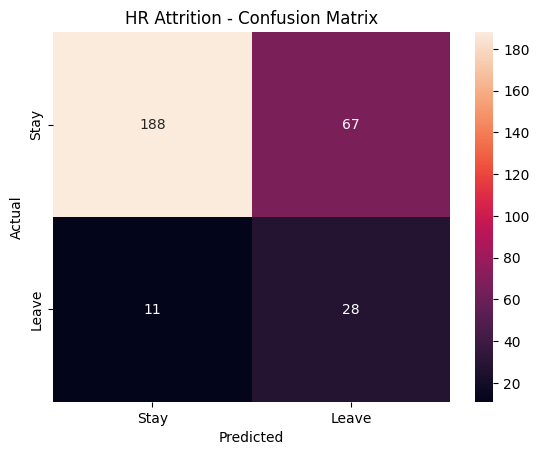

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Stay', 'Leave'], yticklabels=['Stay', 'Leave'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("HR Attrition - Confusion Matrix")
plt.show()

SAVING MODEL NOW

In [24]:
import joblib
joblib.dump(best_lr, "Hr_model.pkl")

['Hr_model.pkl']

In [25]:
loaded_model = joblib.load('Hr_model.pkl')
print(loaded_model.score(X_test, y_test))

0.7346938775510204
